In [1]:
import pandas as pd

# Load the Excel file
excel_path = "Case Study Data.xlsx"
xls = pd.ExcelFile(excel_path)

In [2]:
# Load data from the sheet
df = pd.read_excel(excel_path, sheet_name='Sheet1')

In [3]:

# Convert 'Year Month' to datetime format
df['Date'] = pd.to_datetime(df['Year Month'], format='%Y%m')

# Extract Year, Month, and Quarter
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.to_period('Q')

In [4]:
# 1. Overall monthly volume trend
volume_overall = df.groupby('Date')['Export Volume'].sum().reset_index(name='Total Volume')

# 2. Volume trend by Export Region and Date
volume_by_region = df.groupby(['Export Region', 'Date'])['Export Volume'].sum().reset_index()

# 3. Volume trend by Customer and Date
volume_by_customer = df.groupby(['Customer', 'Date'])['Export Volume'].sum().reset_index()

# 4. Volume trend by Quarter
volume_by_quarter = df.groupby('Quarter')['Export Volume'].sum().reset_index()

# 5. Volume trend by Year
volume_by_year = df.groupby('Year')['Export Volume'].sum().reset_index()


In [6]:
# Optional: Print or export to CSV/Excel
print("Overall Monthly Volume:\n", volume_overall.head())
print("\nVolume by Region:\n", volume_by_region.head())
print("\nVolume by Customer:\n", volume_by_customer.head())
print("\nVolume by Quarter:\n", volume_by_quarter.head())
print("\nVolume by Year:\n", volume_by_year.head())


Overall Monthly Volume:
         Date  Total Volume
0 2023-01-01   153320.5125
1 2023-02-01   201538.3275
2 2023-03-01   260396.4150
3 2023-04-01   263725.5825
4 2023-05-01   269799.4125

Volume by Region:
   Export Region       Date  Export Volume
0          ASIA 2023-01-01      55615.995
1          ASIA 2023-02-01      66717.765
2          ASIA 2023-03-01     102242.475
3          ASIA 2023-04-01     108461.700
4          ASIA 2023-05-01     115337.475

Volume by Customer:
   Customer       Date  Export Volume
0    GNP 1 2023-01-01      5669.0100
1    GNP 1 2023-02-01      7994.4300
2    GNP 1 2023-03-01      9839.7675
3    GNP 1 2023-04-01      9893.1150
4    GNP 1 2023-05-01     10145.7450

Volume by Quarter:
   Quarter  Export Volume
0  2023Q1    615255.2550
1  2023Q2    807375.1725
2  2023Q3    889281.1800
3  2023Q4    869217.5475
4  2024Q1    845017.6275

Volume by Year:
    Year  Export Volume
0  2023   3.181129e+06
1  2024   3.520432e+06


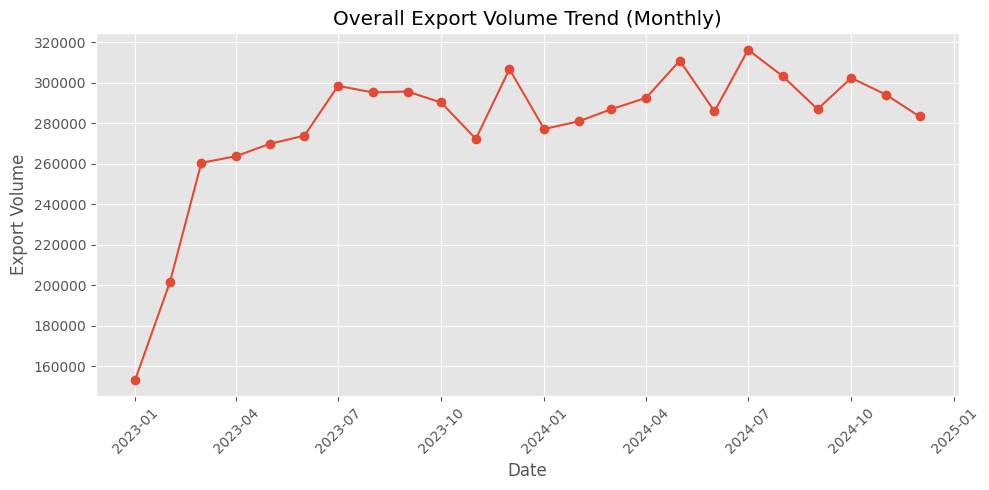

In [7]:
import matplotlib.pyplot as plt

plt.style.use('ggplot')

# 1. Overall Volume Trend Over Time
plt.figure(figsize=(10, 5))
plt.plot(volume_overall['Date'], volume_overall['Total Volume'], marker='o')
plt.title('Overall Export Volume Trend (Monthly)')
plt.xlabel('Date')
plt.ylabel('Export Volume')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

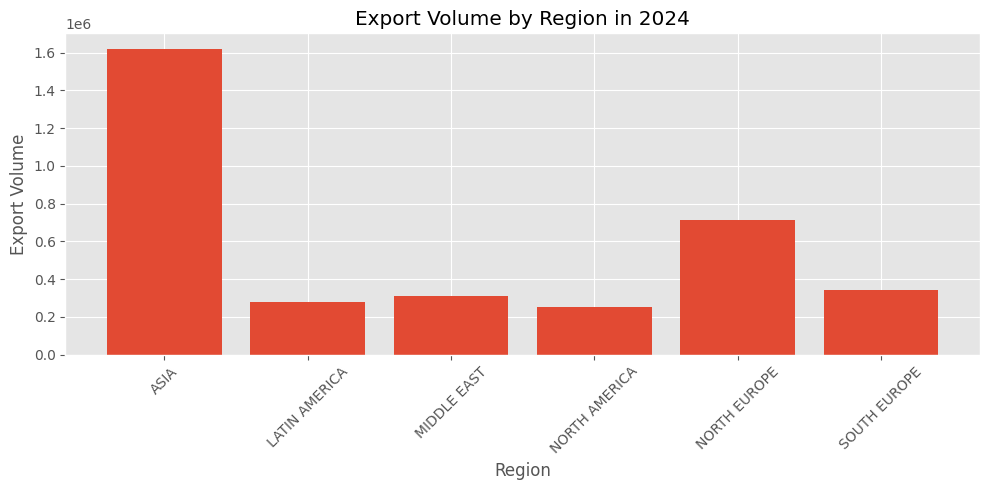

In [8]:
# 2. Volume by Region (Latest Year)
latest_year = df['Year'].max()
region_year = df[df['Year'] == latest_year].groupby('Export Region')['Export Volume'].sum().reset_index()

plt.figure(figsize=(10, 5))
plt.bar(region_year['Export Region'], region_year['Export Volume'])
plt.title(f'Export Volume by Region in {latest_year}')
plt.xlabel('Region')
plt.ylabel('Export Volume')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

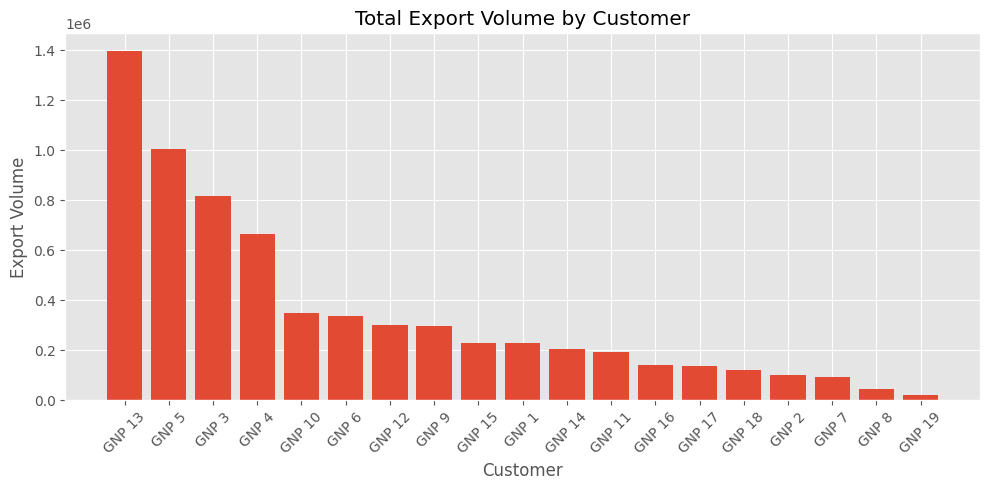

In [9]:
# 3. Volume by Customer (Overall)
customer_total = df.groupby('Customer')['Export Volume'].sum().reset_index().sort_values(by='Export Volume', ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(customer_total['Customer'], customer_total['Export Volume'])
plt.title('Total Export Volume by Customer')
plt.xlabel('Customer')
plt.ylabel('Export Volume')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

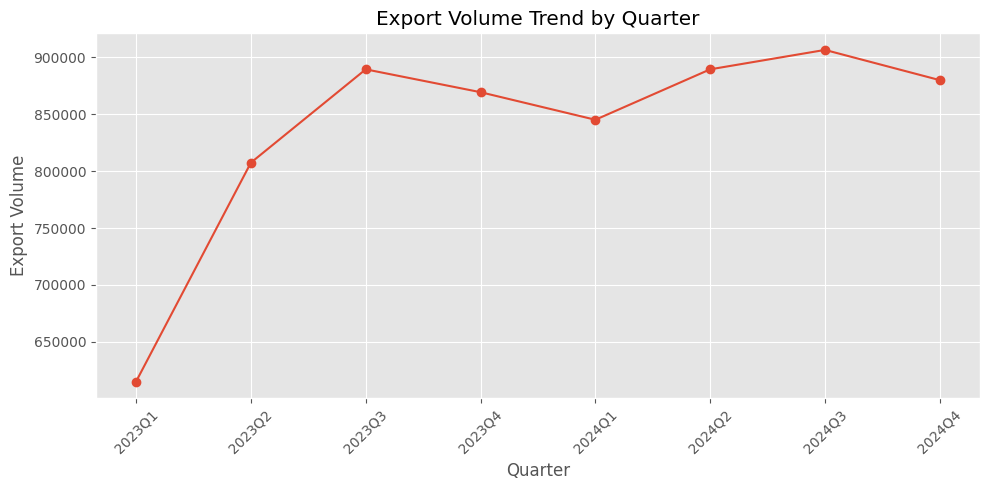

In [10]:
# 4. Quarterly Trend
plt.figure(figsize=(10, 5))
plt.plot(volume_by_quarter['Quarter'].astype(str), volume_by_quarter['Export Volume'], marker='o')
plt.title('Export Volume Trend by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Export Volume')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


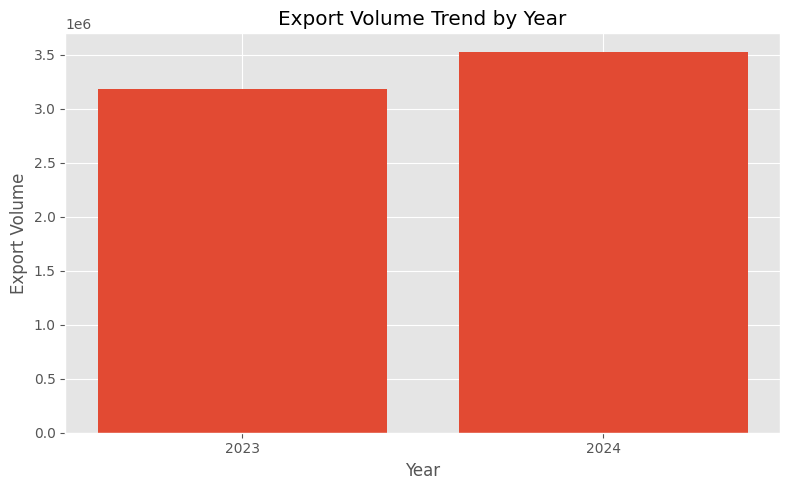

In [11]:
# 5. Yearly Trend
plt.figure(figsize=(8, 5))
plt.bar(volume_by_year['Year'].astype(str), volume_by_year['Export Volume'])
plt.title('Export Volume Trend by Year')
plt.xlabel('Year')
plt.ylabel('Export Volume')
plt.tight_layout()
plt.show()

In [ ]:
# Total volume across all months
total_volume = df['Export Volume'].sum()
# Average monthly volume
avg_monthly_volume = round(volume_overall['Total Volume'].mean(), 2)
# Peak month
monthly_peak_volume = volume_overall['Total Volume'].max()
monthly_peak_date = volume_overall.loc[volume_overall['Total Volume'].idxmax(), 'Date']

# Peak quarter
quarterly_peak_volume = volume_by_quarter['Export Volume'].max()
quarterly_peak = volume_by_quarter.loc[volume_by_quarter['Export Volume'].idxmax(), 'Quarter']

# Total volume by year
total_volume_by_year = volume_by_year.set_index('Year')['Export Volume'].to_dict()

volume_by_year['YoY Growth (%)'] = volume_by_year['Export Volume'].pct_change() * 100
# Calculate Year-over-Year growth
volume_by_year['YoY Growth (%)'] = volume_by_year['Export Volume'].pct_change() * 100
volume_by_year['YoY Growth (%)'] = volume_by_year['YoY Growth (%)'].round(2)

# Now safe to extract the dictionary
yoy_growth = volume_by_year.set_index('Year')['YoY Growth (%)'].to_dict()
# Year-on-Year growth percentage
yoy_growth = volume_by_year.set_index('Year')['YoY Growth (%)'].to_dict()

# Top region
region_total = df.groupby('Export Region')['Year'='2024']['Export Volume'].sum()
top_region = region_total.idxmax()
top_region_volume = region_total.max()

# Top customers
top_customers = customer_total.head(3)

# Volume by top customers
top_customer_stats = top_customers.set_index('Customer')['Export Volume'].to_dict()

# Volume by region
region_stats = region_total.sort_values(ascending=False).to_dict()

# Prepare output as dictionary
key_metrics = {
    'Total Volume (All Time)': round(total_volume, 2),
    'Average Monthly Volume': avg_monthly_volume,
    'Monthly Peak Volume': round(monthly_peak_volume, 2),
    'Monthly Peak Date': monthly_peak_date.strftime('%B %Y'),
    'Quarterly Peak': str(quarterly_peak),
    'Quarterly Peak Volume': round(quarterly_peak_volume, 2),
    'Yearly Volumes': total_volume_by_year,
    'Yearly Growth (%)': yoy_growth,
    'Top Region': top_region,
    'Top Region Volume': round(top_region_volume, 2),
    'Top Customers': top_customer_stats,
    'Top Regions': region_stats
}

import pprint
pprint.pprint(key_metrics)

{'Average Monthly Volume': np.float64(279231.7),
 'Monthly Peak Date': 'July 2024',
 'Monthly Peak Volume': np.float64(316245.08),
 'Quarterly Peak': '2024Q3',
 'Quarterly Peak Volume': np.float64(906331.88),
 'Top Customers': {'GNP 13': 1398595.545,
                   'GNP 3': 817161.03,
                   'GNP 5': 1007080.29},
 'Top Region': 'ASIA',
 'Top Region Volume': np.float64(2939597.66),
 'Top Regions': {'ASIA': 2939597.6625,
                 'LATIN AMERICA': 559541.2275,
                 'MIDDLE EAST': 623267.9550000001,
                 'NORTH AMERICA': 498141.49500000005,
                 'NORTH EUROPE': 1392289.56,
                 'SOUTH EUROPE': 688722.9975},
 'Total Volume (All Time)': np.float64(6701560.9),
 'Yearly Growth (%)': {2023: nan, 2024: 10.67},
 'Yearly Volumes': {2023: 3181129.1550000003, 2024: 3520431.7425}}
